 # Real World Case Example:
 Suppose we want to analyze bicycle sales data at a bicycle shop over the last few
 years. This sales data is an example of a time series. Here is how we can identify
 trends, seasonality, and cyclicality in this data:

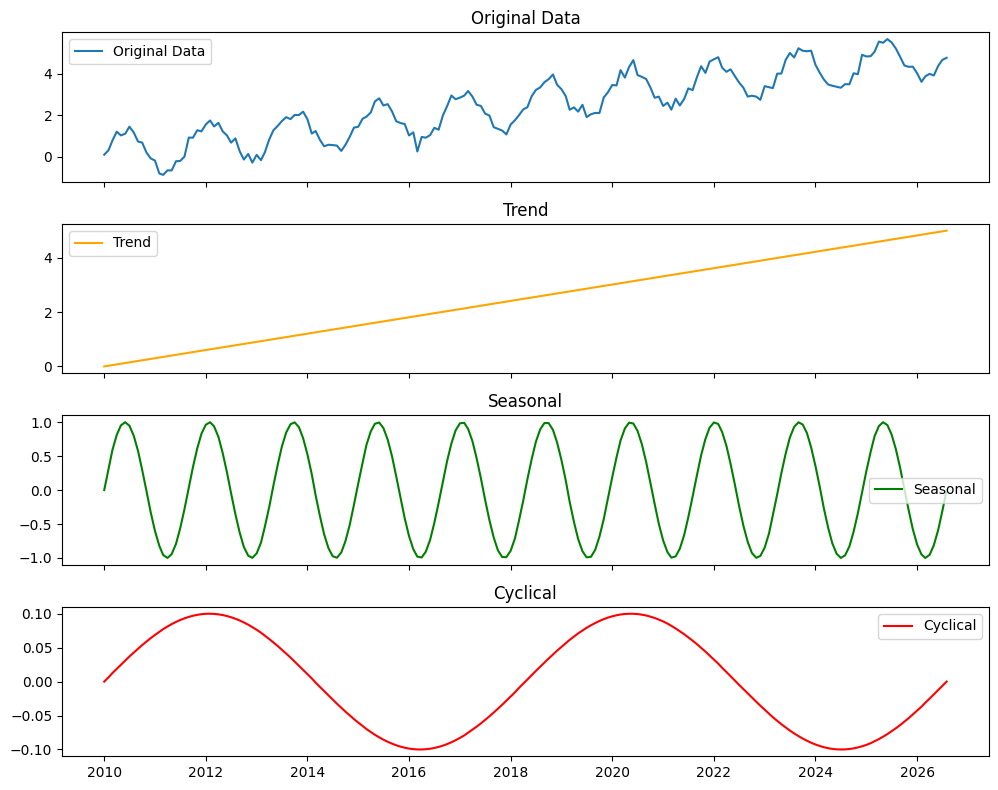

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate synthetic time series data
np.random.seed(42)
n = 200
t = np.linspace(0, 10, n)
trend = 0.5 * t
seasonal = np.sin(2 * np.pi * t)
cyclical = 0.1 * np.sin(2 * np.pi * t / 5)
noise = 0.2 * np.random.normal(size=n)
data = trend + seasonal + cyclical + noise

# Create DataFrame
df = pd.DataFrame(data, columns=['Sales'])
df.index = pd.date_range(start='2010-01-01', periods=n, freq='MS')

# Plot time series components
fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

ax[0].plot(df.index, df['Sales'], label='Original Data')
ax[0].set_title('Original Data')
ax[0].legend()

ax[1].plot(df.index, trend, label='Trend', color='orange')
ax[1].set_title('Trend')
ax[1].legend()

ax[2].plot(df.index, seasonal, label='Seasonal', color='green')
ax[2].set_title('Seasonal')
ax[2].legend()

ax[3].plot(df.index, cyclical, label='Cyclical', color='red')
ax[3].set_title('Cyclical')
ax[3].legend()

plt.tight_layout()
plt.show()


 # Real World Case Example:

 Suppose you have monthly sales data for a product from January to December. You
 want to reduce monthly fluctuations in the data and identify underlying sales
 trends. One way to do this is to use a Moving Average.
 Example Python Script with Synthetic Data:

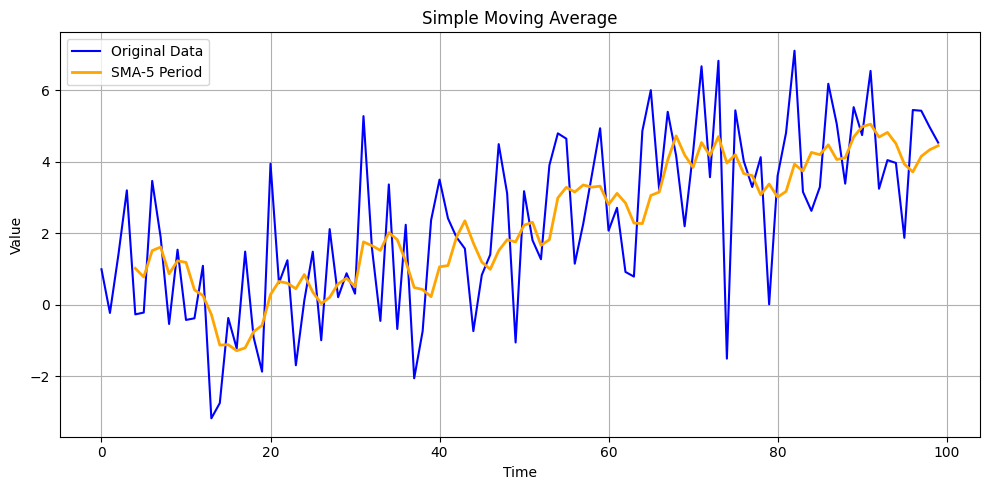

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create synthetic time series data
np.random.seed(42)
n = 100
trend = np.linspace(0, 5, n)
noise = 2 * np.random.normal(size=n)
data = trend + noise

# Calculate Simple Moving Average (SMA)
window_size = 5
sma = pd.Series(data).rolling(window=window_size).mean()

# Plot original data and SMA
plt.figure(figsize=(10, 5))
plt.plot(data, label='Original Data', color='blue')
plt.plot(sma, label=f'SMA-{window_size} Period', color='orange', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Simple Moving Average')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


 # Real World Case Example:
 Suppose you have daily temperature data for a city throughout the year and you
 want to reduce daily fluctuations in the data to identify seasonal patterns. One way
 to do this is to use Exponential Smoothing.

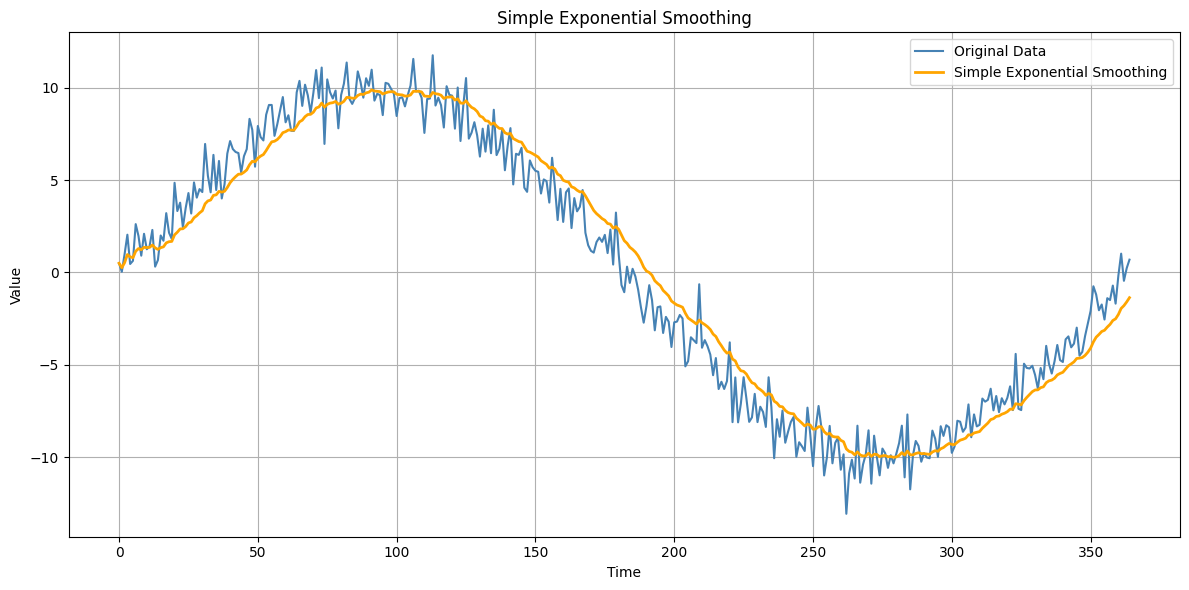

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create synthetic seasonal data with noise
np.random.seed(42)
n = 365  # e.g., one data point per day for a year
seasonal = 10 * np.sin(np.linspace(0, 2 * np.pi, n))  # single seasonal cycle
noise = np.random.normal(size=n)  # random noise
data = seasonal + noise  # combine seasonal pattern with noise

# Apply Simple Exponential Smoothing (SES)
alpha = 0.1  # smoothing factor (0 < alpha <= 1)
ses = pd.Series(data).ewm(alpha=alpha).mean()

# Plot original data and SES result
plt.figure(figsize=(12, 6))
plt.plot(data, label='Original Data', color='steelblue')
plt.plot(ses, label='Simple Exponential Smoothing', color='orange', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Simple Exponential Smoothing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


 Let’s say you work for an airline and want to predict the number of passengers in
 the next few months to help with resource planning. You have monthly passenger
 number data for the last few years and want to use the ARIMA model to make
 predictions.
 Example Python Script with Synthetic Data:

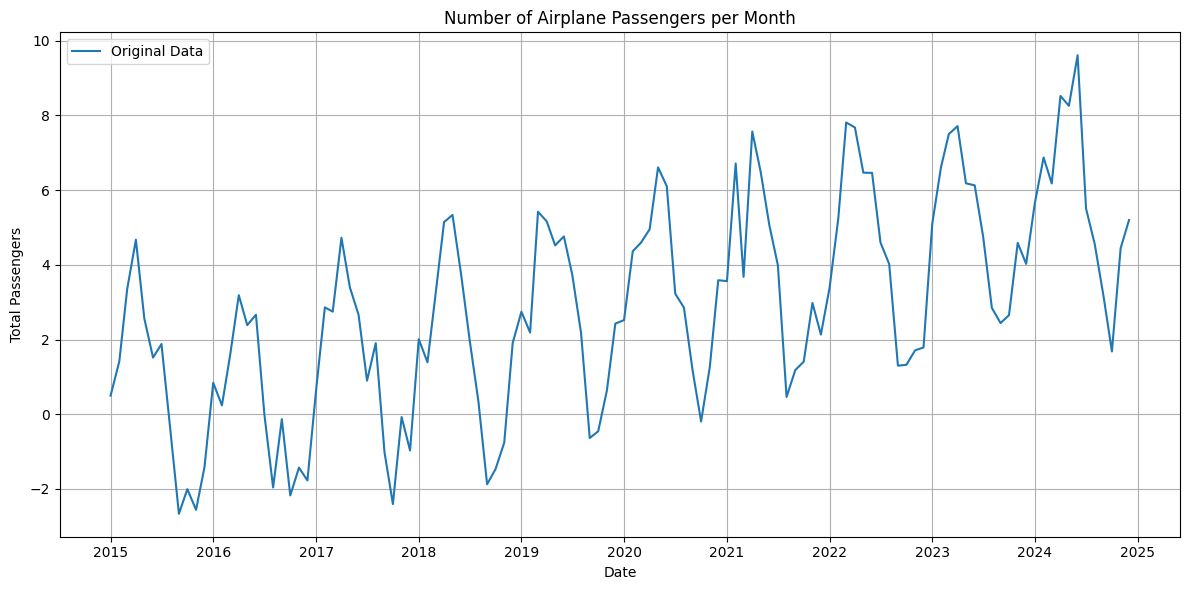

ADF Statistic : 0.633431
P-Value       : 0.988411
⚠️ The series is likely non-stationary.


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



📈 Prediction of Number of Passengers for the Next 6 Months:
2025-01-01    5.307212
2025-02-01    5.347870
2025-03-01    5.363571
2025-04-01    5.369635
2025-05-01    5.371976
2025-06-01    5.372881
Freq: MS, Name: predicted_mean, dtype: float64


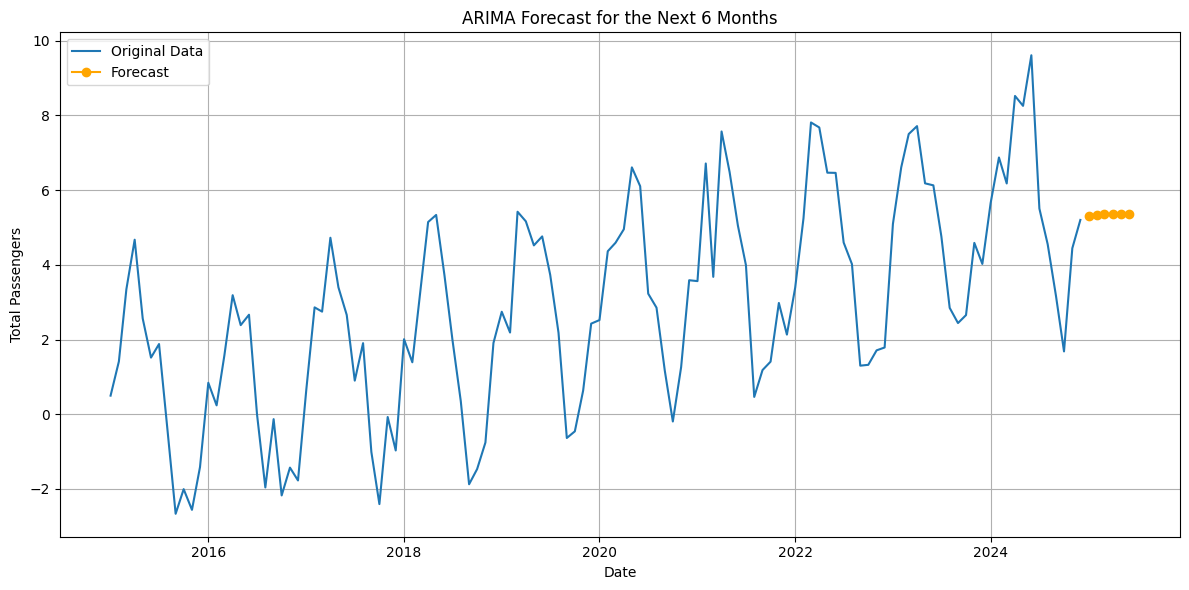

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- 1. Create synthetic data ---
np.random.seed(42)
n = 120  # 10 years of monthly data

trend = 0.05 * np.arange(n)  # small upward trend
seasonal = 3 * np.sin(2 * np.pi * np.arange(n) / 12)  # yearly seasonality
noise = np.random.normal(0, 1, n)  # random noise
data = trend + seasonal + noise  # final synthetic time series

# --- 2. Create DataFrame with dates ---
date_rng = pd.date_range(start='1/1/2015', periods=n, freq='MS')
df = pd.DataFrame({'date': date_rng, 'passengers': data})
df.set_index('date', inplace=True)

# --- 3. Visualize original data ---
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['passengers'], label='Original Data')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.title('Number of Airplane Passengers per Month')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- 4. Augmented Dickey-Fuller Test for stationarity ---
result = adfuller(df['passengers'])
print('ADF Statistic : %f' % result[0])
print('P-Value       : %f' % result[1])
if result[1] < 0.05:
    print("✅ The series is likely stationary.")
else:
    print("⚠️ The series is likely non-stationary.")

# --- 5. First differencing to make stationary ---
df['passengers_diff'] = df['passengers'].diff()

# # --- 6. ACF and PACF plots ---
# fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# plot_acf(df['passengers_diff'].dropna(), ax=axes[0], lags=30)
# plot_pacf(df['passengers_diff'].dropna(), ax=axes[1], lags=30)
# axes[0].set_title("ACF of Differenced Series")
# axes[1].set_title("PACF of Differenced Series")
# plt.tight_layout()
# plt.show()

# --- 7. Fit ARIMA model (p=1, d=1, q=1) ---
model = ARIMA(df['passengers'], order=(1, 1, 1))
model_fit = model.fit()

# --- 8. Forecast next 6 months ---
forecast = model_fit.forecast(steps=6)
print('\n📈 Prediction of Number of Passengers for the Next 6 Months:')
print(forecast)

# --- 9. Plot forecast with original data ---
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['passengers'], label='Original Data')
future_dates = pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(1), periods=6, freq='MS')
plt.plot(future_dates, forecast, label='Forecast', marker='o', color='orange')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.title('ARIMA Forecast for the Next 6 Months')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Real World Case Example: Product Sales Analysis
Let’s say you work in a retail company and want to analyze product sales over the past few years to identify seasonal patterns, trends, and other factors that influence sales. You can use the STL method to decompose sales data and gain useful insights.

Example Python Script with Synthetic Data:

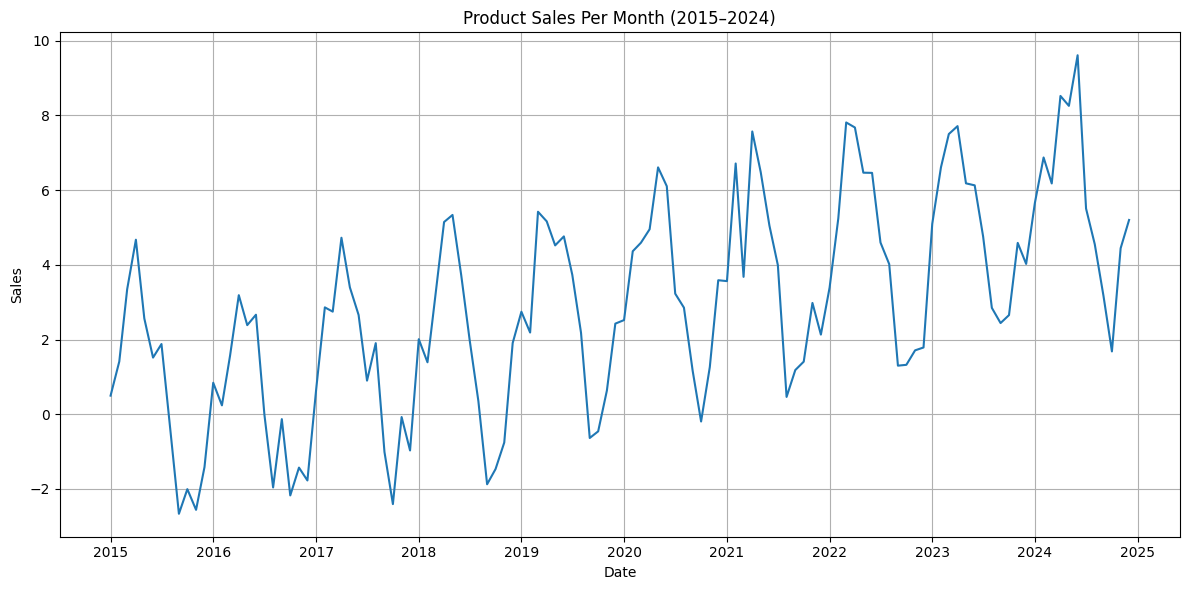

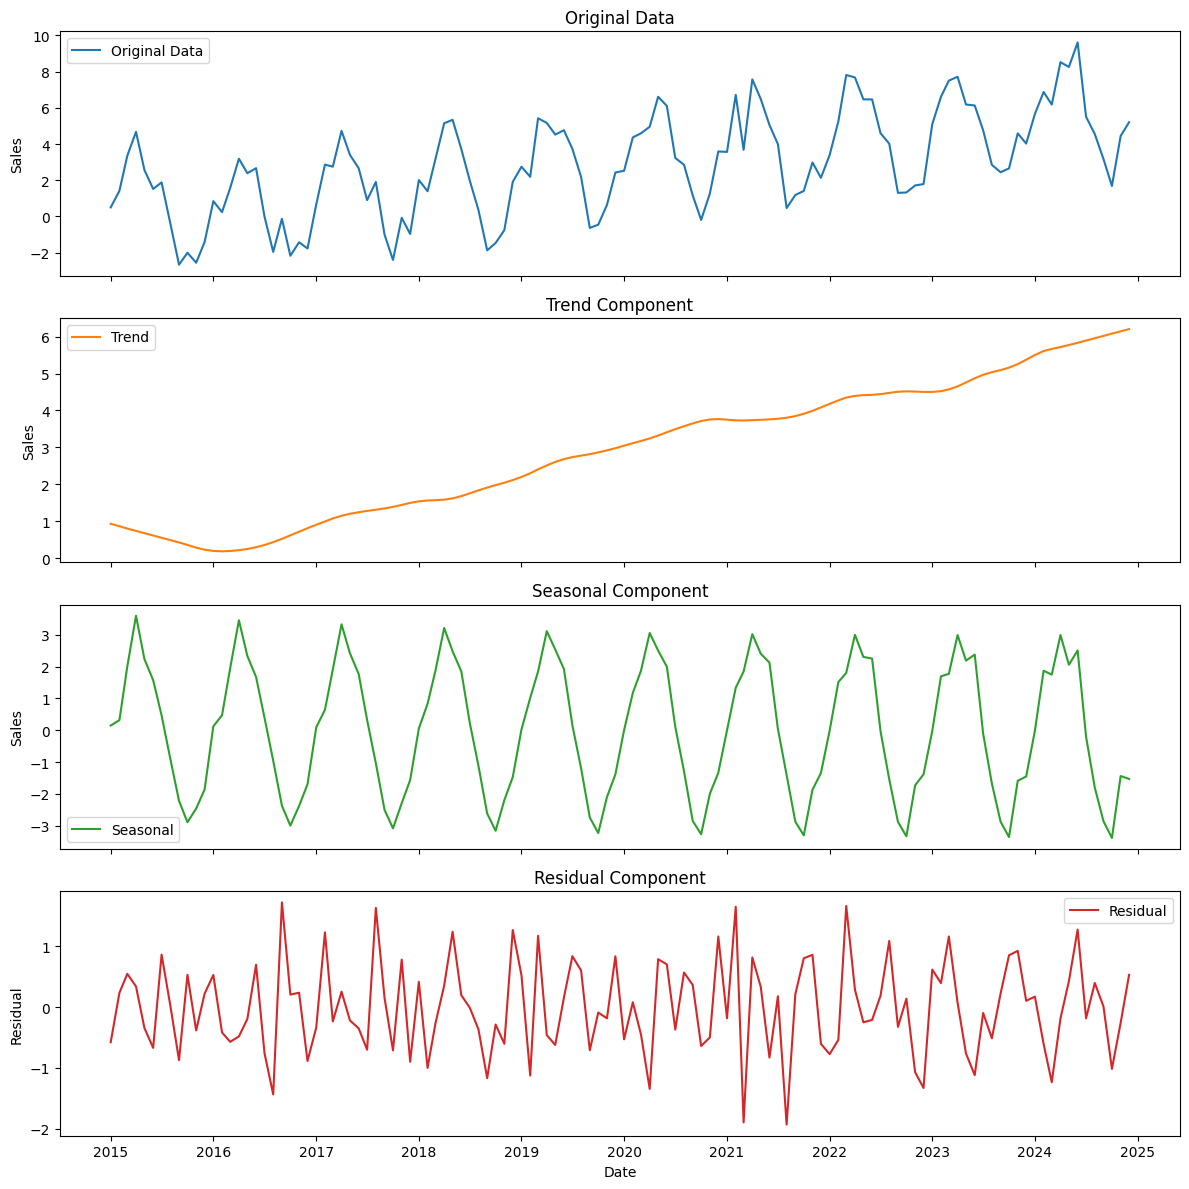

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# --- 1. Create synthetic time series data ---
np.random.seed(42)
n = 120  # 10 years of monthly data
trend = 0.05 * np.arange(n)
seasonal = 3 * np.sin(2 * np.pi * np.arange(n) / 12)
noise = np.random.normal(0, 1, n)
data = trend + seasonal + noise

# --- 2. Create DataFrame ---
date_rng = pd.date_range(start='1/1/2015', periods=n, freq='MS')
df = pd.DataFrame({'date': date_rng, 'sales': data})
df.set_index('date', inplace=True)

# --- 3. Plot original data ---
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['sales'])
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Product Sales Per Month (2015–2024)')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 4. Perform STL decomposition ---
stl = STL(df['sales'], seasonal=13)  # 12-month seasonality + buffer
result = stl.fit()

# --- 5. Plot decomposition components ---
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(df.index, df['sales'], label='Original Data')
axes[0].set_title('Original Data')
axes[0].set_ylabel('Sales')
axes[0].legend()

axes[1].plot(df.index, result.trend, label='Trend', color='C1')
axes[1].set_title('Trend Component')
axes[1].set_ylabel('Sales')
axes[1].legend()

axes[2].plot(df.index, result.seasonal, label='Seasonal', color='C2')  # ✅ fixed line
axes[2].set_title('Seasonal Component')
axes[2].set_ylabel('Sales')
axes[2].legend()

axes[3].plot(df.index, result.resid, label='Residual', color='C3')
axes[3].set_title('Residual Component')
axes[3].set_ylabel('Residual')
axes[3].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()
